<a href="https://colab.research.google.com/github/ThienPhu2708/2001230673_PhungDuongThienPhu_THDeepLearning_Buoi2/blob/main/2001230673_PhungDuongThienPhu_TH_DeepLearning_Buoi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# BÀI THỰC HÀNH: Chuẩn hóa dữ liệu + TensorFlow/Keras
# Dataset: 23_HOMES.csv
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)




TensorFlow version: 2.20.0


In [ ]:
# ── GOLDEN RULE ─────────────────────────────────
print("""
╔══════════════════════════════════════════════════════╗
║  GOLDEN RULE — Chống Data Leakage                    ║
║                                                      ║
║  1. Split FIRST  (train / val / test)                ║
║  2. Fit preprocessor trên TRAIN only                 ║
║  3. Transform tất cả sets với CÙNG preprocessor      ║
║  4. Train model trên train, tune trên val            ║
║  5. Evaluate trên TEST — chỉ 1 lần duy nhất          ║
╚══════════════════════════════════════════════════════╝
""")

In [ ]:
#------------Đọc dataset--------------------------
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/23_HOMES.csv"
df = pd.read_csv(url)

print("\nShape:", df.shape)
print("\nCác cột + kiểu dữ liệu:")
print(df.dtypes)
print("\nMẫu dữ liệu:")
print(df.head())
print("\nGiá trị null:")
print(df.isnull().sum())


Shape: (40, 9)

Các cột + kiểu dữ liệu:
Selling_Price      int64
List_Price         int64
Area               int64
Acres            float64
Age                int64
Taxes              int64
Rooms              int64
Bedrooms           int64
Baths_full         int64
dtype: object

Mẫu dữ liệu:
   Selling_Price  List_Price  Area  Acres  Age  Taxes  Rooms  Bedrooms  \
0         400000      414000  2704   2.27   27   4920      9         3   
1         370000      379000  2096   0.75   21   4113      8         4   
2         382500      389900  2737   1.00   36   6072      9         4   
3         300000      299900  1800   0.43   34   4024      8         4   
4         305000      319900  1066   3.60   69   3562      6         3   

   Baths_full  
0           3  
1           2  
2           2  
3           2  
4           2  

Giá trị null:
Selling_Price    0
List_Price       0
Area             0
Acres            0
Age              0
Taxes            0
Rooms            0
Bedrooms         

In [ ]:
# ── 2. XÁC ĐỊNH FEATURES & TARGET ───────────────────────────
target_col = df.columns[-1]   # cột cuối — verify lại!
feature_cols = df.columns[:-1].tolist()

numeric_features     = df[feature_cols].select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = df[feature_cols].select_dtypes(include=['object','category']).columns.tolist()

print(f"\nTarget     : {target_col}")
print(f"Numeric    : {numeric_features}")
print(f"Categorical: {categorical_features}")

X = df[feature_cols]
y = df[target_col].values.astype(float)


Target     : Baths_full
Numeric    : ['Selling_Price', 'List_Price', 'Area', 'Acres', 'Age', 'Taxes', 'Rooms', 'Bedrooms']
Categorical: []


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu")


Train: 32 mẫu | Test: 8 mẫu


In [ ]:
preprocessors = []
if numeric_features:
    preprocessors.append(("num", MinMaxScaler(), numeric_features))
if categorical_features:
    preprocessors.append(("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features))

preprocess = ColumnTransformer(preprocessors)

# fit CHỈ trên X_train → không rò rỉ test info
preprocess.fit(X_train)

X_train_processed = preprocess.transform(X_train)
X_test_processed  = preprocess.transform(X_test)

print(f"\nShape sau preprocessing:")
print(f"  X_train: {X_train_processed.shape}")
print(f"  X_test : {X_test_processed.shape}")

input_dim = X_train_processed.shape[1]


Shape sau preprocessing:
  X_train: (32, 8)
  X_test : (8, 8)


In [ ]:
# ── 5. XÂY DỰNG MODEL TENSORFLOW/KERAS ──────────────────────
print("\n" + "="*50)
print("5. TENSORFLOW/KERAS MODEL")
print("="*50)

def build_model(input_dim):
    model = keras.Sequential([
         layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),          # thêm Dropout chống overfit
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',   # Adam: thuật toán tối ưu phổ biến, tự điều chỉnh learning rate
        loss='mse',         # Loss function: Mean Squared Error (sai số bình phương trung bình)
        metrics=['mae']     # Metric theo dõi: Mean Absolute Error (dễ đọc hơn MSE)
    )
    return model

model = build_model(input_dim)
model.summary()  # In cấu trúc mô hình: số lớp, số tham số mỗi lớp


5. TENSORFLOW/KERAS MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── 6. TRAIN MODEL ───────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping

print("\n" + "="*50)
print("6. TRAINING")
print("="*50)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# Dùng validation_split để theo dõi overfitting — KHÔNG dùng test set
history = model.fit(
    X_train_processed, y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2,   # tách 20% train làm validation (không phải test!)
    callbacks=[early_stop],   # tự dừng khi val_loss không cải thiện
    verbose=1
)


6. TRAINING
Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 5.5972 - mae: 2.2107 - val_loss: 5.7924 - val_mae: 2.1299
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.7317 - mae: 2.0404 - val_loss: 5.3879 - val_mae: 2.0499
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.2753 - mae: 1.9385 - val_loss: 5.0231 - val_mae: 1.9761
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.0333 - mae: 1.8843 - val_loss: 4.6929 - val_mae: 1.9064
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 3.7511 - mae: 1.8238 - val_loss: 4.3933 - val_mae: 1.8409
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3.4006 - mae: 1.7249 - val_loss: 4.1595 - val_mae: 1.7841
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 3.0512 - mae: 1.6408 - val_loss: 3.9469 - val_mae: 1.7308
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2.6531 - mae: 1.5168 - val_loss: 3.7268 - val_mae: 1.6734
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 

In [ ]:
# ── 7. ĐÁNH GIÁ TRÊN TEST SET (chỉ 1 lần cuối) ──────────────
print("\n" + "="*50)
print("7. ĐÁNH GIÁ TRÊN TEST SET — dùng đúng 1 lần")
print("="*50)

test_loss, test_mae = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test MSE : {test_loss:.4f}")
print(f"Test MAE : {test_mae:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

y_pred = model.predict(X_test_processed).flatten()

comparison = pd.DataFrame({
    'Actual'   : y_test[:5].round(2),
    'Predicted': y_pred[:5].round(2),
    'Error'    : (y_test[:5] - y_pred[:5]).round(2)
})
print("\nActual vs Predicted (5 mẫu đầu):")
print(comparison)


7. ĐÁNH GIÁ TRÊN TEST SET — dùng đúng 1 lần
Test MSE : 0.6787
Test MAE : 0.7037
Test RMSE: 0.8238
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

Actual vs Predicted (5 mẫu đầu):
   Actual  Predicted  Error
0     1.0       1.23  -0.23
1     2.0       1.28   0.72
2     2.0       3.59  -1.59
3     2.0       2.70  -0.70
4     2.0       1.79   0.21


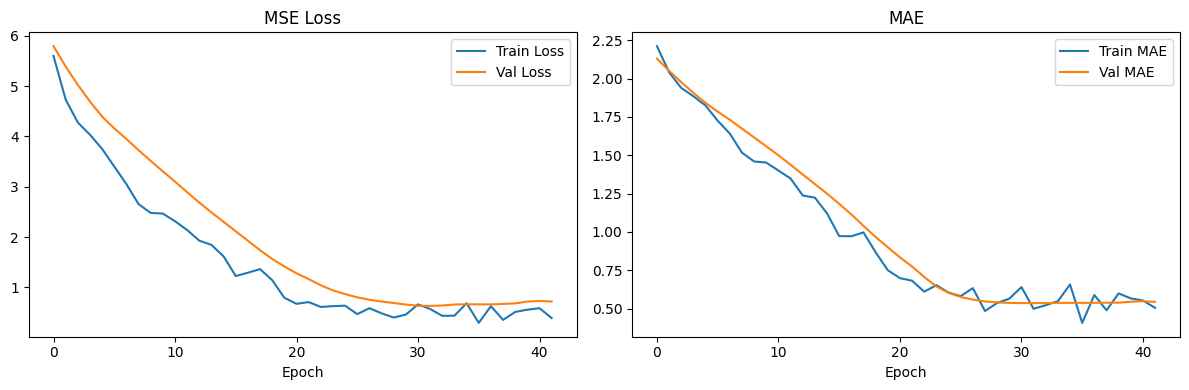

In [ ]:
# ── 8. VẼ LOSS CURVE ─────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()